In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from src import corpus,keymap,optimization

from tqdm import tqdm

In [80]:
char_freqs,bigram_matrix,chars=corpus.get_matrix_from_json("ressources/fre_en.json")

POP_SIZE =200  # Population size for genetic algorithm
GENS = 200  # Number of generations
MUTATION_RATE = 0.5  # Probability of mutation
layout_cost=lambda layout: optimization.layout_cost(layout,char_freqs,bigram_matrix)



In [82]:

ergo_chords=keymap.generate_ergonomic_chords()

In [83]:
import random

In [84]:
best_score = []
population = [keymap.generate_random_layout(ergo_chords,chars) for _ in range(POP_SIZE)]
# population = [[hash(str(layout)) for layout in indiv] for indiv in population__]

progress=tqdm(range(GENS))
for _ in progress:
    population = sorted(population, key=layout_cost) 
    progress.set_description(str(layout_cost(population[0])))
    
        # Rank by cost
    best_score.append(layout_cost(population[0]))
    next_gen = population[:POP_SIZE // 2]  # Keep best 50%
    
    while len(next_gen) < POP_SIZE:
        p1, p2 = random.sample(population[:POP_SIZE // 4], 2)  # Select top candidates
        child = keymap.crossover(p1, p2)
        child = keymap.mutate(child, ergo_chords,MUTATION_RATE)
        next_gen.append(child)
    
    population = next_gen  # Move to next generation

best_layout=sorted(population, key=layout_cost)[0]  # Best layout

1.3766165514325286: 100%|██████████| 200/200 [01:31<00:00,  2.18it/s]


In [95]:
print(best_layout)

[array([[False, False, False, False],
       [ True, False, False, False]]), array([[False, False, False, False],
       [False,  True, False, False]]), array([[False, False, False, False],
       [False, False,  True, False]]), array([[False,  True, False, False],
       [False, False, False, False]]), array([[ True, False, False, False],
       [False, False, False, False]]), array([[False, False, False,  True],
       [False, False, False, False]]), array([[False, False,  True, False],
       [False, False, False, False]]), array([[False, False, False, False],
       [False, False, False,  True]]), array([[False,  True,  True, False],
       [False, False, False, False]]), array([[False,  True, False, False],
       [False,  True, False, False]]), array([[ True, False,  True, False],
       [False, False, False, False]]), array([[False, False,  True, False],
       [False, False, False,  True]]), array([[ True, False, False, False],
       [ True, False, False, False]]), array([[Fal

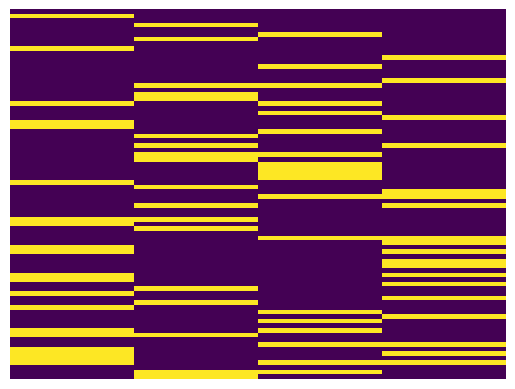

In [96]:
keymap.plot_layout(best_layout,chars)

In [87]:
chars

['e',
 't',
 'a',
 's',
 'i',
 'n',
 'o',
 'r',
 'l',
 'd',
 'u',
 'c',
 'h',
 'm',
 'p',
 'f',
 'g',
 'v',
 'é',
 'b',
 '.',
 'y',
 ',',
 'w',
 "'",
 'q',
 'k',
 '*',
 'x',
 'j',
 '-',
 'à',
 'z',
 ';',
 '/',
 '=',
 ']',
 '[',
 '\\',
 '`']

True


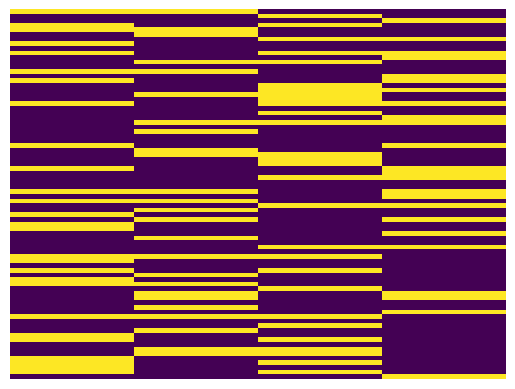

In [88]:
random_layout=keymap.generate_random_layout(ergo_chords,chars)
print(keymap.check_uniqueness_of_chords(random_layout))
keymap.plot_layout(random_layout,chars)

In [89]:
keymap.hashable_chord(random_layout[0])

-4269477172556237785

In [90]:
keymap.mutate(random_layout,ergo_chords,1)
print(keymap.check_uniqueness_of_chords(keymap.mutate(random_layout,ergo_chords,0.1)))

True


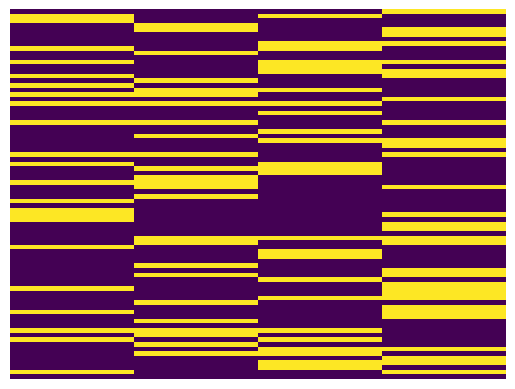

In [91]:
p1=keymap.generate_random_layout(ergo_chords,chars)
p2=keymap.generate_random_layout(ergo_chords,chars)
keymap.plot_layout(keymap.crossover(p1,p2),chars)

In [92]:
print(keymap.check_uniqueness_of_chords(keymap.crossover(p1,p2)))

True


In [93]:
random_layout2=random_layout.copy()
random_layout2[0]=random_layout2[1]
print(keymap.check_uniqueness_of_chords(random_layout2))

False


In [94]:
type(keymap.hashable_chord(random_layout[1]))

int